In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
import numpy as np
import pickle

from rdkit import RDLogger

RDLogger.DisableLog('rdApp.*')

def calc_fps(smis, fp_func):
    fps = [fp_func(Chem.MolFromSmiles(smi)) for smi in smis]
    return fps

def fit_decomp_kde(fps_train, pipe, kde):
    
    X_train_decomp = pipe.fit_transform(fps_train)
    kde.fit(X_train_decomp)
    
    return X_train_decomp

def plot_decomp_kde(X_decomp, kde, ax):
        
    X, Y = np.meshgrid(np.linspace(-1.1, 1.1, 100), np.linspace(-1.1, 1.1, 100))
    Z = np.vstack([Y.ravel(), X.ravel()]).T
    # density at gridpoints
    Z = np.exp(kde.score_samples(Z)).reshape(100,100)

    # kernel density countour plot
    levels = np.linspace(0, Z.max(), 25)
    m = ax.contourf(X, Y, Z, levels=levels, cmap=plt.cm.Reds)
    sns.scatterplot(x=X_decomp[:, 0], y=X_decomp[:, 1], s=2, ax=ax)

    ax.grid(True)
    
    return X_decomp

In [21]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=3).GetFingerprint
#fpgen = rdFingerprintGenerator.GetAtomPairGenerator().GetFingerprint

kde = KernelDensity(kernel="gaussian", bandwidth=0.5)
pipe = Pipeline([('decomp', PCA(n_components=2)), ('scaler', MinMaxScaler((-1,1)))])
#pipe = Pipeline([('decomp', Isomap(n_components=2, n_neighbors=200)), ('scaler', MinMaxScaler((-1,1)))])

smis_train = [i.rstrip() for i in open("/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/data/HCs/PCCP/hydros8992.smi").readlines()]
fps_train = calc_fps(smis_train, fpgen)
X_train_decomp = fit_decomp_kde(fps_train, pipe, kde)

smis_test = [i.rstrip() for i in open("/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/data/HCs/pubchem_with_flex/pubchem_HCs_inc_flex.smi").readlines()]
fps_test = calc_fps(smis_test, fpgen)
X_test_decomp = pipe.transform(fps_test)

smis_gen = [i.rstrip() for i in open("/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/scratch_programs/random_mol_gen/hydros_augmented_even/valid.smi").readlines()]
fps_gen = calc_fps(smis_gen, fpgen)
X_gen_decomp = pipe.transform(fps_gen)

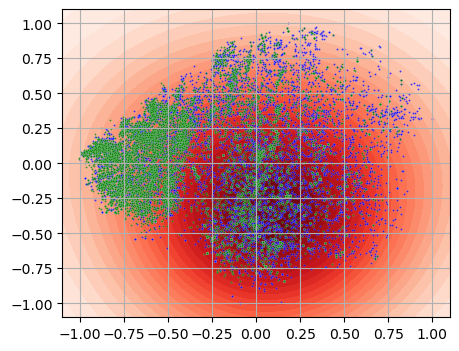

In [22]:
fig, ax = plt.subplots(figsize=(5, 4))
X, Y = np.meshgrid(np.linspace(-1.1, 1.1, 100), np.linspace(-1.1, 1.1, 100))
Z = np.vstack([Y.ravel(), X.ravel()]).T
# density at gridpoints
Z = np.exp(kde.score_samples(Z)).reshape(100,100)

# kernel density countour plot
levels = np.linspace(0, Z.max(), 25)
m = ax.contourf(X, Y, Z, levels=levels, cmap=plt.cm.Reds)
# sns.scatterplot(x=X_test_decomp[:, 0], y=X_test_decomp[:, 1], s=2, ax=ax, alpha=0.75, color="black")
sns.scatterplot(x=X_train_decomp[:, 0], y=X_train_decomp[:, 1], s=2, ax=ax, alpha=0.75, color="blue")
sns.scatterplot(x=X_gen_decomp[:, 0], y=X_gen_decomp[:, 1], s=2, ax=ax, alpha=0.75, color="green")

ax.grid(True)
plt.show()

In [10]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=3).GetFingerprint
#fpgen = rdFingerprintGenerator.GetAtomPairGenerator().GetFingerprint

kde = KernelDensity(kernel="gaussian", bandwidth=0.5)
pipe = Pipeline([('decomp', PCA(n_components=2)), ('scaler', MinMaxScaler((-1,1)))])
#pipe = Pipeline([('decomp', Isomap(n_components=2, n_neighbors=200)), ('scaler', MinMaxScaler((-1,1)))])

smis_train = [i.rstrip() for i in open("/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/data/HCs/pubchem_with_flex/pubchem_HCs_inc_flex.smi").readlines()]
fps_train = calc_fps(smis_train, fpgen)
X_train_decomp = fit_decomp_kde(fps_train, pipe, kde)

smis_test = [i.rstrip() for i in open("/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/data/HCs/PCCP/hydros8992.smi").readlines()]
fps_test = calc_fps(smis_test, fpgen)
X_test_decomp = pipe.transform(fps_test)

<Axes: >

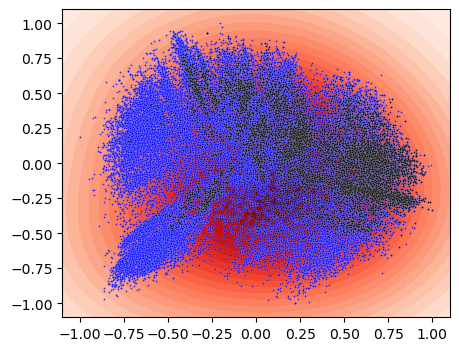

In [20]:
fig, ax = plt.subplots(figsize=(5, 4))
X, Y = np.meshgrid(np.linspace(-1.1, 1.1, 100), np.linspace(-1.1, 1.1, 100))
Z = np.vstack([Y.ravel(), X.ravel()]).T
# density at gridpoints
Z = np.exp(kde.score_samples(Z)).reshape(100,100)

# kernel density countour plot
levels = np.linspace(0, Z.max(), 25)
m = ax.contourf(X, Y, Z, levels=levels, cmap=plt.cm.Reds)
sns.scatterplot(x=X_train_decomp[:, 0], y=X_train_decomp[:, 1], s=2, ax=ax, alpha=0.75, color="blue")
sns.scatterplot(x=X_test_decomp[:, 0], y=X_test_decomp[:, 1], s=2, ax=ax, alpha=0.75, color="black")
# sns.scatterplot(x=X_gen_decomp[:, 0], y=X_gen_decomp[:, 1], s=2, ax=ax, alpha=0.75, color="green")

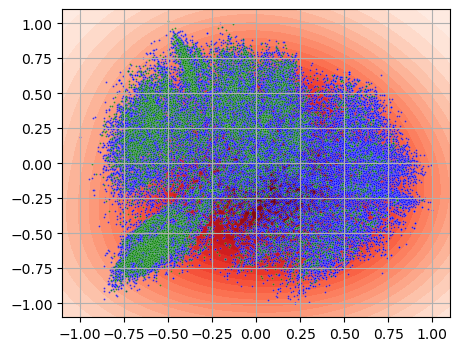

In [18]:
smis_gen = [i.rstrip() for i in open("/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/scratch_programs/random_mol_gen/results_larger_dataset/valid.smi").readlines()]
fps_gen = calc_fps(smis_gen, fpgen)
X_gen_decomp = pipe.transform(fps_gen)

fig, ax = plt.subplots(figsize=(5, 4))
m = ax.contourf(X, Y, Z, levels=levels, cmap=plt.cm.Reds)
sns.scatterplot(x=X_train_decomp[:, 0], y=X_train_decomp[:, 1], s=2, ax=ax, alpha=0.75, color="blue")
sns.scatterplot(x=X_gen_decomp[:, 0], y=X_gen_decomp[:, 1], s=2, ax=ax, alpha=0.75, color="green")

ax.grid(True)
plt.show()